<a href="https://colab.research.google.com/github/muajnstu/Plan_Crash_Prediction_-_Topic_Modelling/blob/main/D2_Implementation_followed_by_a_data_balancing_pipeline_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pipeline Overview**
1. Install & Import
2. All Function Definitions
3. Data Loading & Preprocessing
4. TF-IDF Vectorisation + LSA
5. KMeans Clustering per Sentiment Class
6. Re-clustering (Synthetic-Minimising Strategy)
7. Cluster Filtering & Label Assignment
8. Applying SMOTE
9. Train / Test Split & Scaling
10. Classic ML — Train
11. Deep Learning — Train (LSTM / GRU / CNN / BiLSTM)
12. Transformer — Train (BERT / RoBERTa / DistilBERT / ALBERT)
13. Results — Compare & Summarise

**Install Dependencies**

In [ ]:
!pip install -q imbalanced-learn xgboost lightgbm transformers torch

**Imports**

In [ ]:
import warnings, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from collections import Counter
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    silhouette_score
)
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Perceptron, SGDClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier,
    BaggingClassifier, ExtraTreesClassifier
)
from sklearn.svm import SVC, LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Conv1D, GlobalMaxPooling1D, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print('All imports successful.')

All imports successful.


**Global Constants**

In [ ]:
# ── Reproducibility
RANDOM_STATE   = 42

# ── TF-IDF / LSA
TFIDF_MAX_FEAT = 1000
LSA_COMPONENTS = 100

# ── KMeans / clustering
KMEANS_INIT    = 10          # n_init for KMeans
MIN_CLUSTER_RATIO = 0.40     # drop clusters below 40% of median size
ABS_MIN_CLUSTER   = 50       # absolute floor for any cluster

# ── Train / test split
TEST_SIZE      = 0.20
VAL_SIZE       = 0.10

# ── Deep Learning
MAX_WORDS      = 20_000      # Tokenizer vocabulary size
MAX_LEN        = 100         # Padded sequence length
EMBED_DIM      = 64          # Embedding dimension
DL_EPOCHS      = 5
DL_BATCH_SIZE  = 32

# ── Transformer
TRANSFORMER_MAX_LEN   = 128
TRANSFORMER_EPOCHS    = 3
TRANSFORMER_BATCH     = 8
TRANSFORMER_LR        = 2e-5

# ── Label map
LABEL_MAP      = {0: 'Positive', 1: 'Negative', 2: 'Mixed'}

# ── classifiers that require scaled input
NEEDS_SCALE = {
    'LogisticRegression', 'RidgeClassifier', 'SGDClassifier', 'Perceptron',
    'GaussianNB', 'BernoulliNB', 'KNeighborsClassifier',
    'LinearDiscriminantAnalysis', 'QuadraticDiscriminantAnalysis',
    'LinearSVC', 'SVC_RBF', 'MLPClassifier',
}

**All Function Definitions**
> Every helper used downstream is defined here. Run this cell once before executing any later section.

In [ ]:
# TEXT PREPROCESSING

_stop_words  = set(stopwords.words('english'))
_lemmatizer  = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """Lowercase → strip non-alpha → remove stopwords → lemmatise."""
    text   = str(text).lower()
    text   = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [_lemmatizer.lemmatize(w) for w in tokens if w not in _stop_words]
    return ' '.join(tokens)

# CLUSTERING HELPERS

def synthetic_count(counts) -> int:
    """Estimate total SMOTE synthetic samples needed to equalise all clusters."""
    m = max(counts)
    return sum(m - c for c in counts)


def plot_elbow_silhouette(X: np.ndarray, title: str) -> int:
    """
    Plot WCSS (elbow) and silhouette score for k = 2..10.
    Returns the best k according to silhouette.
    """
    wcss, sil_scores, k_range = [], [], range(2, 11)
    for k in k_range:
        km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=KMEANS_INIT)
        labels = km.fit_predict(X)
        wcss.append(km.inertia_)
        sil_scores.append(silhouette_score(X, labels, sample_size=min(2000, len(X))))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(k_range, wcss, marker='o')
    ax1.set_title(f'{title} — WCSS (Elbow)')
    ax1.set_xlabel('k'); ax1.set_ylabel('WCSS')

    ax2.plot(k_range, sil_scores, marker='s', color='darkorange')
    ax2.set_title(f'{title} — Silhouette Score')
    ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette')

    plt.tight_layout(); plt.show()
    best_k = list(k_range)[sil_scores.index(max(sil_scores))]
    print(f'  Best k by silhouette: {best_k} (score={max(sil_scores):.3f})')
    return best_k


def split_large_clusters(
    X: np.ndarray,
    labels: np.ndarray,
    min_cluster_size: int = ABS_MIN_CLUSTER
) -> np.ndarray:
    """
    Iteratively split the largest cluster until no cluster exceeds the
    second-largest. Uses silhouette to pick the best sub-k.
    """
    new_labels = np.array(labels, dtype=object)
    for iteration in range(1, 50):
        unique, counts = np.unique(new_labels, return_counts=True)
        order          = np.argsort(-counts)
        unique, counts = unique[order], counts[order]
        if len(unique) < 2 or counts[0] <= counts[1]:
            break

        largest_name, largest_size, second_size = unique[0], counts[0], counts[1]
        k_min = math.ceil(largest_size / second_size)
        k_max = k_min + 2
        idx   = np.where(new_labels == largest_name)[0]
        X_sub = X[idx]
        print(f'Iter {iteration}: splitting "{largest_name}" '
              f'(n={largest_size}) into k={k_min}…{k_max} (second={second_size})')

        best_k, best_score, best_sublabels = None, -np.inf, None
        for k in range(k_min, k_max + 1):
            if k >= len(idx): break
            km        = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=KMEANS_INIT)
            sub_lbl   = km.fit_predict(X_sub)
            sub_counts = np.bincount(sub_lbl)
            if sub_counts.min() < min_cluster_size:
                print(f'  k={k} rejected: smallest={sub_counts.min()} < {min_cluster_size}')
                continue
            sil = silhouette_score(X_sub, sub_lbl, sample_size=min(2000, len(X_sub)))
            print(f'  k={k}: sizes={sorted(sub_counts, reverse=True)}, sil={sil:.3f}')
            if sil > best_score:
                best_score, best_k, best_sublabels = sil, k, sub_lbl

        if best_k is None:
            print(f'  No valid split for "{largest_name}" — stopping.'); break

        for i, sub in zip(idx, best_sublabels):
            new_labels[i] = f'{largest_name}_{sub}'
        new_counts = np.bincount(best_sublabels)
        print(f'  => k={best_k} (sil={best_score:.3f}), sizes={sorted(new_counts, reverse=True)}')
        print(f'  => Synthetic count: {synthetic_count(np.unique(new_labels, return_counts=True)[1]):,}\n')

    return new_labels

# TRAIN / TEST SPLIT & SCALING


def split_and_scale(
    X: np.ndarray,
    y: np.ndarray,
    test_size: float = TEST_SIZE,
    val_size: float  = VAL_SIZE
):
    """
    Stratified 80 / 10 / 10 split (train / val / test) + StandardScaler.

    Returns
    -------
    X_train, X_val, X_test       : raw (unscaled) splits
    X_train_sc, X_val_sc, X_test_sc : scaled splits
    y_train, y_val, y_test       : label arrays
    scaler                       : fitted StandardScaler
    """
    # First split: train+val vs test
    X_tv, X_test, y_tv, y_test = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )
    # Second split: train vs val
    val_frac = val_size / (1.0 - test_size)          # relative fraction
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=val_frac, random_state=RANDOM_STATE, stratify=y_tv
    )

    scaler      = StandardScaler()
    X_train_sc  = scaler.fit_transform(X_train)
    X_val_sc    = scaler.transform(X_val)
    X_test_sc   = scaler.transform(X_test)

    print(f'Train : {X_train_sc.shape} | class dist: {Counter(y_train)}')
    print(f'Val   : {X_val_sc.shape}   | class dist: {Counter(y_val)}')
    print(f'Test  : {X_test_sc.shape}  | class dist: {Counter(y_test)}')

    return (X_train, X_val, X_test,
            X_train_sc, X_val_sc, X_test_sc,
            y_train, y_val, y_test,
            scaler)

# METRICS

def calculate_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_proba: np.ndarray | None,
    model_name: str
) -> dict:
    """
    Compute accuracy, precision, recall, weighted-F1, and macro-AUC.
    y_proba : (n_samples, n_classes) probability matrix, or None to skip AUC.

    Returns a dict suitable for pd.DataFrame.from_dict(orient='index').
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    if y_proba is not None:
        try:
            auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        except ValueError:
            auc = float('nan')
    else:
        auc = float('nan')

    return {
        'Model'    : model_name,
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
        'F1'       : round(f1,   4),
        'AUC'      : round(auc,  4),
    }

#   CLASSIC ML

def build_classifiers() -> dict:
    """Return a fresh dict of (name → unfitted classifier)."""
    return {
        # Linear
        'LogisticRegression'         : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
        'RidgeClassifier'            : RidgeClassifier(class_weight='balanced'),
        'SGDClassifier'              : SGDClassifier(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
        'Perceptron'                 : Perceptron(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
        # Naive Bayes
        'GaussianNB'                 : GaussianNB(),
        'BernoulliNB'                : BernoulliNB(),
        # Distance
        'KNeighborsClassifier'       : KNeighborsClassifier(n_neighbors=5),
        # Discriminant
        'LinearDiscriminantAnalysis' : LinearDiscriminantAnalysis(),
        'QuadraticDiscriminantAnalysis': QuadraticDiscriminantAnalysis(reg_param=0.1),
        # Tree
        'DecisionTreeClassifier'     : DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
        #'ExtraTreeClassifier'        : ExtraTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
        # Ensemble
        'RandomForestClassifier'     : RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1),
        'ExtraTreesClassifier'       : ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1),
        'AdaBoostClassifier'         : AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
        'GradientBoostingClassifier' : GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
        'BaggingClassifier'          : BaggingClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
        # SVM
        'LinearSVC'                  : LinearSVC(max_iter=2000, random_state=RANDOM_STATE, class_weight='balanced'),
        'SVC_RBF'                    : SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE, class_weight='balanced'),
        # Gradient boosting (external)
        'XGBClassifier'              : XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0),
        'LGBMClassifier'             : LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced', verbosity=-1),
        # Neural
        'MLPClassifier'              : MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300, random_state=RANDOM_STATE),
    }


def run_classic_ml(
    X_train: np.ndarray, X_test: np.ndarray,
    X_train_sc: np.ndarray, X_test_sc: np.ndarray,
    y_train: np.ndarray, y_test: np.ndarray
) -> dict:
    """
    Train all classic ML classifiers and collect metrics.
    Prints a one-line summary per model; full results returned as a dict.

    Returns
    -------
    dict  {model_name: metrics_dict}
    """
    classifiers = build_classifiers()
    results     = {}

    print(f'{"Model":<36}  {"Acc":>6}  {"F1":>6}  {"AUC":>6}  {"Time":>6}')
    print('-' * 65)

    for name, clf in classifiers.items():
        Xtr = X_train_sc if name in NEEDS_SCALE else X_train
        Xte = X_test_sc  if name in NEEDS_SCALE else X_test

        t0 = time.time()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            clf.fit(Xtr, y_train)
            y_pred = clf.predict(Xte)
        elapsed = time.time() - t0

        # Probability matrix for AUC (not all classifiers support predict_proba)
        y_proba = None
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            if hasattr(clf, 'predict_proba'):
                y_proba = clf.predict_proba(Xte)
            elif hasattr(clf, 'decision_function'):
                df = clf.decision_function(Xte)
                # Convert decision scores to pseudo-probabilities via softmax
                e  = np.exp(df - df.max(axis=1, keepdims=True))
                y_proba = e / e.sum(axis=1, keepdims=True)

        m = calculate_metrics(y_test, y_pred, y_proba, name)
        m['Time(s)'] = round(elapsed, 2)
        results[name] = m

        print(f'{name:<36}  {m["Accuracy"]:>6.4f}  {m["F1"]:>6.4f}  '
              f'{m["AUC"]:>6.4f}  {elapsed:>5.1f}s')

    return results

# DEEP LEARNING  (Keras)

def prepare_dl_data(
    X_train_raw, X_val_raw, X_test_raw,
    y_train: np.ndarray, y_val: np.ndarray, y_test: np.ndarray
):
    """
    Tokenise + pad text sequences for Keras DL models.
    X_* inputs should be arrays / Series of raw (pre-cleaned) text strings.

    Returns
    -------
    X_train_seq, X_val_seq, X_test_seq  : padded integer sequences
    y_train, y_val, y_test              : numpy label arrays
    tokenizer                           : fitted Keras Tokenizer
    """
    tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
    tokenizer.fit_on_texts(X_train_raw)

    def _seq(X):
        return pad_sequences(tokenizer.texts_to_sequences(X), maxlen=MAX_LEN)

    X_train_seq = _seq(X_train_raw)
    X_val_seq   = _seq(X_val_raw)
    X_test_seq  = _seq(X_test_raw)

    if hasattr(y_train, 'values'): y_train = y_train.values
    if hasattr(y_val,   'values'): y_val   = y_val.values
    if hasattr(y_test,  'values'): y_test  = y_test.values

    print(f'DL sequences — train: {X_train_seq.shape}, val: {X_val_seq.shape}, test: {X_test_seq.shape}')
    return X_train_seq, X_val_seq, X_test_seq, y_train, y_val, y_test, tokenizer


def create_lstm() -> Sequential:
    return Sequential([
        Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
        LSTM(128),
        Dense(3, activation='softmax')
    ])

def create_gru() -> Sequential:
    return Sequential([
        Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
        GRU(128),
        Dense(3, activation='softmax')
    ])

def create_cnn() -> Sequential:
    return Sequential([
        Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
        Conv1D(128, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(3, activation='softmax')
    ])

def create_bilstm() -> Sequential:
    return Sequential([
        Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
        Bidirectional(LSTM(128)),
        Dense(3, activation='softmax')
    ])


def train_dl_model(
    name: str,
    model_fn,
    X_train_seq: np.ndarray, y_train: np.ndarray,
    X_val_seq: np.ndarray,   y_val: np.ndarray,
    X_test_seq: np.ndarray,  y_test: np.ndarray
) -> dict:
    """
    Compile, train, and evaluate one Keras model.
    Returns a metrics dict (same shape as calculate_metrics output).
    """
    print(f'\nTraining {name}...')
    model = model_fn()
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    model.fit(
        X_train_seq, y_train,
        epochs=DL_EPOCHS,
        batch_size=DL_BATCH_SIZE,
        validation_data=(X_val_seq, y_val),
        verbose=1
    )
    y_proba = model.predict(X_test_seq, verbose=0)
    y_pred  = np.argmax(y_proba, axis=1)
    return calculate_metrics(y_test, y_pred, y_proba, name)


def run_dl_models(
    X_train_seq, y_train_dl,
    X_val_seq,   y_val_dl,
    X_test_seq,  y_test_dl
) -> dict:
    """
    Train all four Keras DL architectures and return a results dict.

    Returns
    -------
    dict  {model_name: metrics_dict}
    """
    dl_architectures = {
        'LSTM'  : create_lstm,
        'GRU'   : create_gru,
        'CNN'   : create_cnn,
        'BiLSTM': create_bilstm,
    }
    dl_results = {}
    for name, fn in dl_architectures.items():
        metrics = train_dl_model(
            name, fn,
            X_train_seq, y_train_dl,
            X_val_seq,   y_val_dl,
            X_test_seq,  y_test_dl
        )
        dl_results[name] = metrics
    return dl_results

# TRANSFORMER  (PyTorch / HuggingFace)

class TorchTextDataset(torch.utils.data.Dataset):
    """Minimal Dataset wrapper for HuggingFace Trainer."""
    def __init__(self, encodings, labels):
        if hasattr(labels, 'values'): labels = labels.values
        self.labels    = torch.tensor(labels, dtype=torch.long)
        self.encodings = encodings

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)


def _tokenize_for_transformer(tokenizer, X, max_length: int = TRANSFORMER_MAX_LEN):
    """Tokenise a text array and return HuggingFace BatchEncoding."""
    return tokenizer(
        list(X),
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )


def train_pytorch_transformer(
    model_name: str,
    checkpoint: str,
    num_labels: int,
    X_train, y_train,
    X_val,   y_val,
    X_test,  y_test,
    max_length: int = TRANSFORMER_MAX_LEN
) -> dict:
    """
    Load a pre-trained transformer, fine-tune via HuggingFace Trainer,
    and evaluate on the test split.

    Returns
    -------
    dict  {metric_name: value}  (same shape as calculate_metrics output)
    """
    print(f'\n{"="*70}\nTRAINING {model_name}\n{"="*70}')
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model     = AutoModelForSequenceClassification.from_pretrained(
        checkpoint, num_labels=num_labels
    )
    model.config.problem_type = 'single_label_classification'

    train_ds = TorchTextDataset(_tokenize_for_transformer(tokenizer, X_train, max_length), y_train)
    val_ds   = TorchTextDataset(_tokenize_for_transformer(tokenizer, X_val,   max_length), y_val)
    test_ds  = TorchTextDataset(_tokenize_for_transformer(tokenizer, X_test,  max_length), y_test)

    training_args = TrainingArguments(
        output_dir=f'./results_{model_name.lower()}',
        num_train_epochs=TRANSFORMER_EPOCHS,
        per_device_train_batch_size=TRANSFORMER_BATCH,
        per_device_eval_batch_size=TRANSFORMER_BATCH,
        learning_rate=TRANSFORMER_LR,
        warmup_ratio=0.1,
        eval_strategy='epoch',
        save_strategy='no',
        logging_strategy='epoch',
        max_grad_norm=1.0,
        report_to='none'
    )
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds
    )
    trainer.train()

    test_outputs = trainer.predict(test_ds)
    logits  = test_outputs.predictions
    y_pred  = np.argmax(logits, axis=1)
    probs   = torch.nn.functional.softmax(torch.tensor(logits), dim=1)
    y_proba = torch.nan_to_num(probs).cpu().numpy()

    return calculate_metrics(y_test if not hasattr(y_test, 'values') else y_test.values,
                             y_pred, y_proba, model_name)


def run_transformer_models(
    X_train, y_train,
    X_val,   y_val,
    X_test,  y_test,
    num_labels: int
) -> dict:
    """
    Fine-tune all configured transformer checkpoints and return a results dict.

    Returns
    -------
    dict  {model_name: metrics_dict}
    """
    transformer_checkpoints = {
        'BERT'      : 'bert-base-uncased',
        'RoBERTa'   : 'roberta-base',
        'DistilBERT': 'distilbert-base-uncased',
        'ALBERT'    : 'albert-base-v2',
        # 'DeBERTa' : 'microsoft/deberta-v3-base',  # uncomment if GPU available
    }
    transformer_results = {}
    for name, ckpt in transformer_checkpoints.items():
        metrics = train_pytorch_transformer(
            name, ckpt, num_labels,
            X_train, y_train,
            X_val,   y_val,
            X_test,  y_test
        )
        transformer_results[name] = metrics
    return transformer_results


# REPORTING

def build_results_df(all_results: dict) -> pd.DataFrame:
    """Convert the combined results dict to a tidy DataFrame sorted by AUC."""
    df = pd.DataFrame.from_dict(all_results, orient='index')
    df.index.name = 'Model'
    df = df.drop(columns=['Model'], errors='ignore')   # index already holds the name
    return df.sort_values('AUC', ascending=False)


def plot_model_comparison(results_df: pd.DataFrame, metric: str = 'F1', top_n: int = 15):
    """Horizontal bar chart for the top-N models by the given metric."""
    top = results_df.sort_values(metric, ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top.index[::-1], top[metric][::-1], color='steelblue')
    ax.set_xlabel(metric)
    ax.set_title(f'Top-{top_n} Models — {metric} (CrFB + SMOTE)')
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, top[metric][::-1]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)
    plt.tight_layout(); plt.show()


def plot_confusion_matrix(y_true, y_pred, model_name: str,
                          class_names=('Positive', 'Negative', 'Mixed')):
    """Plot a labelled confusion matrix for the given predictions."""
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}')
    plt.tight_layout(); plt.show()


print('All functions defined.')

All functions defined.


**Data Loading & Preprocessing**

In [ ]:
url = 'https://raw.githubusercontent.com/muajnstu/Airlines_Review_Analysis_and_Topic_Modelling/refs/heads/main/Dataset_2.csv?token=GHSAT0AAAAAADSXKJFXLP774UNVKREDQWDO2QFUIOQ'
df  = pd.read_csv(url)
print(df.head())
print('\nSentiment distribution:')
print(df['sentiment'].value_counts())

                                              review sentiment
0  Hong Kong to Brisbane via Taipei. Hong Kong to...  Negative
1  Jakarta to Vancouver via Taipei. First time fl...  Positive
2  Myself my mother and my husband flew Gatwick t...  Negative
3  They have no regard for consumer rights and wi...  Negative
4  The check-in in this case was a bit more compl...     Mixed

Sentiment distribution:
sentiment
Negative    3494
Positive    2037
Mixed       1547
Name: count, dtype: int64


In [ ]:
df_cleaned = df.copy()

# Drop duplicates
before = df_cleaned.shape
df_cleaned = df_cleaned.drop_duplicates()
print(f'Duplicates removed: {before[0] - df_cleaned.shape[0]} rows')
print(f'Shape: {before} → {df_cleaned.shape}')

# Clean text
df_cleaned['review'] = df_cleaned['review'].apply(clean_text)
print('\nSample cleaned reviews:')
print(df_cleaned['review'].head())

Duplicates removed: 1 rows
Shape: (7078, 2) → (7077, 2)

Sample cleaned reviews:
0    hong kong brisbane via taipei hong kong taipei...
1    jakarta vancouver via taipei first time flying...
2    mother husband flew gatwick sydney via taipei ...
3    regard consumer right destroy itinerary dont e...
4    checkin case bit complex flight ability taipei...
Name: review, dtype: object


**TF-IDF Vectorisation + LSA (Dimensionality Reduction)**

In [ ]:
tfidf = TfidfVectorizer(max_features=TFIDF_MAX_FEAT, stop_words=list(_stop_words))
X_vectorized = tfidf.fit_transform(df_cleaned['review'])
print('TF-IDF shape:', X_vectorized.shape)

svd = TruncatedSVD(n_components=LSA_COMPONENTS, random_state=RANDOM_STATE)
X_reduced = svd.fit_transform(X_vectorized)
explained = svd.explained_variance_ratio_.sum()
print(f'LSA: {LSA_COMPONENTS} components explain {explained:.1%} of variance')
print('Reduced shape:', X_reduced.shape)

TF-IDF shape: (7077, 1000)
LSA: 100 components explain 33.5% of variance
Reduced shape: (7077, 100)


**Clustering per Sentiment Class**

In [ ]:
y_labels = df_cleaned['sentiment'].values

X_pos = X_reduced[y_labels == 'Positive']
X_neg = X_reduced[y_labels == 'Negative']
X_neu = X_reduced[y_labels == 'Mixed']

print('Positive:', X_pos.shape)
print('Negative:', X_neg.shape)
print('Mixed   :', X_neu.shape)

Positive: (2037, 100)
Negative: (3494, 100)
Mixed   : (1546, 100)


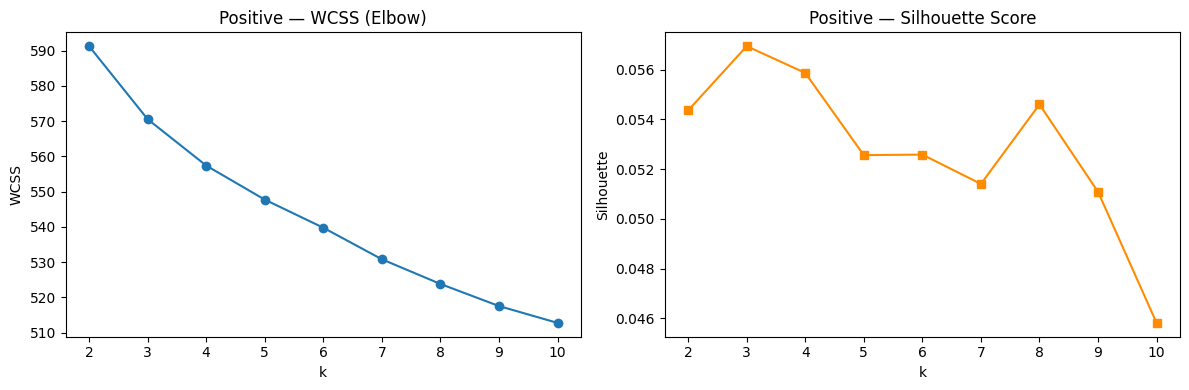

  Best k by silhouette: 3 (score=0.057)


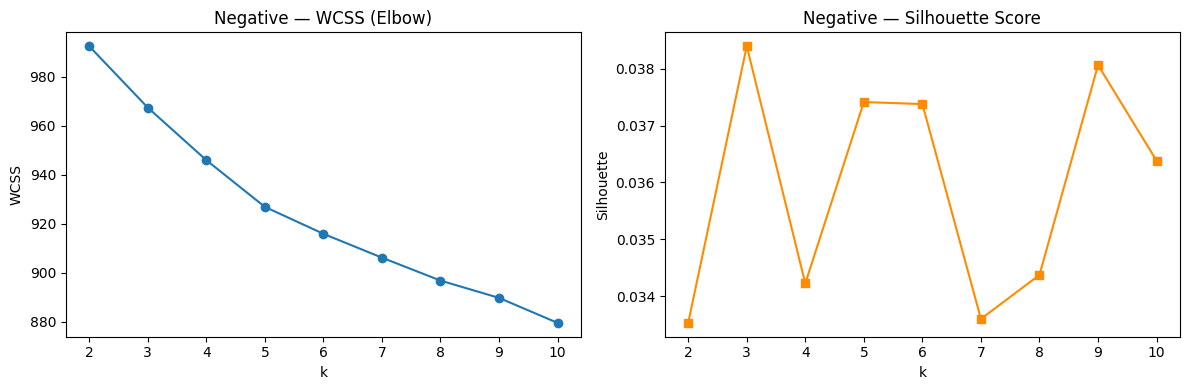

  Best k by silhouette: 3 (score=0.038)


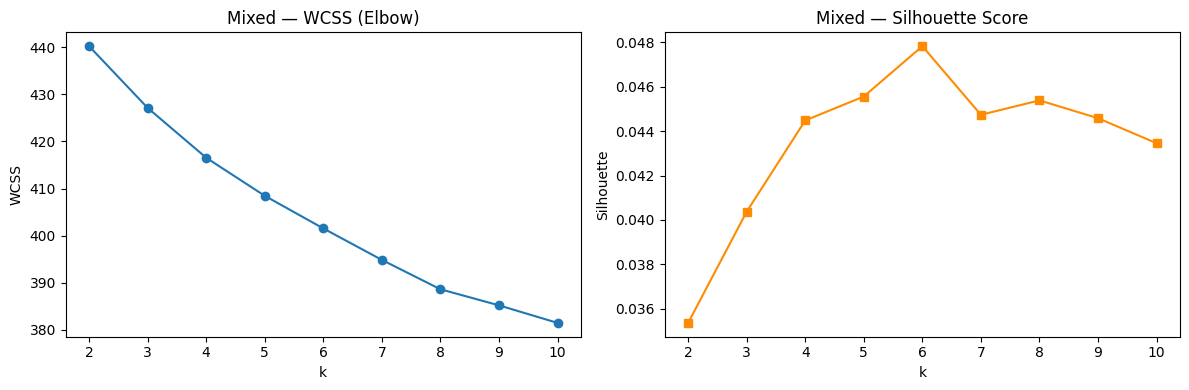

  Best k by silhouette: 6 (score=0.048)


In [ ]:
# Elbow + silhouette — inspect plots before proceeding
best_k_pos = plot_elbow_silhouette(X_pos, 'Positive')
best_k_neg = plot_elbow_silhouette(X_neg, 'Negative')
best_k_neu = plot_elbow_silhouette(X_neu, 'Mixed')

In [ ]:
# Override any k here if the plots suggest a different choice
n_clusters_positive = best_k_pos
n_clusters_negative = best_k_neg
n_clusters_neutral  = best_k_neu

km_pos = KMeans(n_clusters=n_clusters_positive, random_state=RANDOM_STATE, n_init=KMEANS_INIT)
km_neg = KMeans(n_clusters=n_clusters_negative, random_state=RANDOM_STATE, n_init=KMEANS_INIT)
km_neu = KMeans(n_clusters=n_clusters_neutral,  random_state=RANDOM_STATE, n_init=KMEANS_INIT)

labels_pos = km_pos.fit_predict(X_pos)
labels_neg = km_neg.fit_predict(X_neg)
labels_neu = km_neu.fit_predict(X_neu)

print('Cluster distribution:')
print('  Positive:', np.bincount(labels_pos))
print('  Negative:', np.bincount(labels_neg))
print('  Mixed   :', np.bincount(labels_neu))

Cluster distribution:
  Positive: [ 574  360 1103]
  Negative: [ 402 1318 1774]
  Mixed   : [204  67 556 219 206 294]


**Cluster + Re-clustering**

In [ ]:
df_pos = pd.DataFrame(X_pos); df_pos['target'] = 'Positive'; df_pos['Cluster_Label'] = ['Positive_' + str(i+1) for i in labels_pos]
df_neg = pd.DataFrame(X_neg); df_neg['target'] = 'Negative'; df_neg['Cluster_Label'] = ['Negative_' + str(i+1) for i in labels_neg]
df_neu = pd.DataFrame(X_neu); df_neu['target'] = 'Mixed';    df_neu['Cluster_Label'] = ['Mixed_'    + str(i+1) for i in labels_neu]

final_df = pd.concat([df_pos, df_neg, df_neu], ignore_index=True)
print('Cluster distribution (initial):')
print(final_df['Cluster_Label'].value_counts())
print(f'\nInitial synthetic count estimate: {synthetic_count(final_df["Cluster_Label"].value_counts().values):,}')

Cluster distribution (initial):
Cluster_Label
Negative_3    1774
Negative_2    1318
Positive_3    1103
Positive_1     574
Mixed_3        556
Negative_1     402
Positive_2     360
Mixed_6        294
Mixed_4        219
Mixed_5        206
Mixed_1        204
Mixed_2         67
Name: count, dtype: int64

Initial synthetic count estimate: 14,211


In [ ]:
X_features   = final_df.drop(columns=['target', 'Cluster_Label']).values
labels_array = final_df['Cluster_Label'].to_numpy()

new_labels = split_large_clusters(X_features, labels_array, min_cluster_size=ABS_MIN_CLUSTER)

counts_after = pd.Series(new_labels).value_counts()
print('\nAfter re-clustering:')
print(counts_after)
print(f'\nFinal synthetic count estimate: {synthetic_count(counts_after.values):,}')
print(f'Max cluster: {counts_after.max()}, Min cluster: {counts_after.min()}')

Iter 1: splitting "Negative_3" (n=1774) into k=2…4 (second=1318)
  k=2: sizes=[np.int64(1337), np.int64(437)], sil=0.039
  k=3: sizes=[np.int64(863), np.int64(521), np.int64(390)], sil=0.033
  k=4: sizes=[np.int64(650), np.int64(515), np.int64(446), np.int64(163)], sil=0.034
  => k=2 (sil=0.039), sizes=[np.int64(1337), np.int64(437)]
  => Synthetic count: 10,304

Iter 2: splitting "Negative_3_0" (n=1337) into k=2…4 (second=1318)
  k=2: sizes=[np.int64(755), np.int64(582)], sil=0.031
  k=3: sizes=[np.int64(621), np.int64(362), np.int64(354)], sil=0.030
  k=4: sizes=[np.int64(591), np.int64(368), np.int64(238), np.int64(140)], sil=0.032
  => k=4 (sil=0.032), sizes=[np.int64(591), np.int64(368), np.int64(238), np.int64(140)]
  => Synthetic count: 14,011

Iter 3: splitting "Negative_2" (n=1318) into k=2…4 (second=1103)
  k=2: sizes=[np.int64(681), np.int64(637)], sil=0.033
  k=3: sizes=[np.int64(500), np.int64(415), np.int64(403)], sil=0.030
  k=4: sizes=[np.int64(458), np.int64(376), np.i

**Filtering & Label Assignment**

In [ ]:
cluster_counts  = pd.Series(new_labels).value_counts()
median_size     = cluster_counts.median()
MIN_CLUSTER_SIZE = max(ABS_MIN_CLUSTER, int(MIN_CLUSTER_RATIO * median_size))

print(f'Median cluster size : {median_size:.0f}')
print(f'Filter threshold    : {MIN_CLUSTER_SIZE}')

small_clusters = cluster_counts[cluster_counts < MIN_CLUSTER_SIZE].index.tolist()
print(f'Clusters to drop ({len(small_clusters)}):', small_clusters)

df_recluster = final_df.copy()
df_recluster['Cluster_Label'] = new_labels
filtered_df  = df_recluster[~df_recluster['Cluster_Label'].isin(small_clusters)].copy()

print('\nShape after filtering:', filtered_df.shape)
print('\nRemaining cluster sizes:')
print(filtered_df['Cluster_Label'].value_counts())

Median cluster size : 273
Filter threshold    : 109
Clusters to drop (4): ['Mixed_2', 'Mixed_3_1', 'Positive_3_2_0', 'Positive_3_1']

Shape after filtering: (6821, 102)

Remaining cluster sizes:
Cluster_Label
Negative_3_0_3_1    466
Negative_2_2        458
Negative_3_1        437
Negative_1          402
Positive_3_2_1      396
Negative_2_3        376
Negative_3_0_1      368
Positive_2          360
Negative_2_0        351
Positive_3_0        344
Positive_1_1        301
Mixed_6             294
Mixed_3_0_1         290
Positive_1_0        273
Positive_3_2_2      241
Negative_3_0_2      238
Mixed_4             219
Mixed_5             206
Mixed_1             204
Mixed_3_0_0         199
Negative_3_0_0      140
Negative_2_1        133
Negative_3_0_3_0    125
Name: count, dtype: int64


In [ ]:
def _sentiment_sort_key(label):
    order = {'Positive': 0, 'Negative': 1, 'Mixed': 2}
    prefix = label.split('_')[0]
    return (order.get(prefix, 99), label)

sorted_labels = sorted(filtered_df['Cluster_Label'].unique(), key=_sentiment_sort_key)
cluster_label_to_serial = {lbl: f'label_{i}' for i, lbl in enumerate(sorted_labels)}

filtered_df['Serial_Cluster_Label'] = (
    filtered_df['Cluster_Label']
    .map(cluster_label_to_serial)
    .apply(lambda x: int(x.split('_')[1]))
)
filtered_df = filtered_df.drop(columns=['Cluster_Label'])

print('Serial cluster distribution:')
print(filtered_df['Serial_Cluster_Label'].value_counts().sort_index())

Serial cluster distribution:
Serial_Cluster_Label
0     273
1     301
2     360
3     344
4     396
5     241
6     402
7     351
8     133
9     458
10    376
11    140
12    368
13    238
14    125
15    466
16    437
17    204
18    199
19    290
20    219
21    206
22    294
Name: count, dtype: int64


**Balancing**

In [ ]:
original_indices = filtered_df.index.values
filtered_df      = filtered_df.reset_index(drop=True)

X_smote_input = filtered_df.drop(columns=['target', 'Serial_Cluster_Label']).values
y_smote_input = filtered_df['Serial_Cluster_Label'].values

print('Class distribution BEFORE SMOTE:')
for k, v in sorted(Counter(y_smote_input).items()):
    print(f'  label_{k}: {v}')

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)
X_balanced, y_balanced_clusters = smote.fit_resample(X_smote_input, y_smote_input)

nn = NearestNeighbors(n_neighbors=1, algorithm='auto').fit(X_smote_input)
_, nn_idx = nn.kneighbors(X_balanced)

df_cleaned_indices = original_indices[nn_idx.flatten()]

print(f'\nAfter SMOTE: {X_balanced.shape[0]:,} total samples '
      f'({X_balanced.shape[0] - len(X_smote_input):,} synthetic added)')
print('Class distribution AFTER SMOTE:')
for k, v in sorted(Counter(y_balanced_clusters).items()):
    print(f'  label_{k}: {v}')

print(f'\nVerification:')
print(f'  X_balanced shape        : {X_balanced.shape}')
print(f'  df_cleaned_indices shape: {df_cleaned_indices.shape}')
assert len(df_cleaned_indices) == len(X_balanced), "Index/feature alignment broken!"
print('  Indices aligned with X_balanced')

Class distribution BEFORE SMOTE:
  label_0: 273
  label_1: 301
  label_2: 360
  label_3: 344
  label_4: 396
  label_5: 241
  label_6: 402
  label_7: 351
  label_8: 133
  label_9: 458
  label_10: 376
  label_11: 140
  label_12: 368
  label_13: 238
  label_14: 125
  label_15: 466
  label_16: 437
  label_17: 204
  label_18: 199
  label_19: 290
  label_20: 219
  label_21: 206
  label_22: 294

After SMOTE: 10,718 total samples (3,897 synthetic added)
Class distribution AFTER SMOTE:
  label_0: 466
  label_1: 466
  label_2: 466
  label_3: 466
  label_4: 466
  label_5: 466
  label_6: 466
  label_7: 466
  label_8: 466
  label_9: 466
  label_10: 466
  label_11: 466
  label_12: 466
  label_13: 466
  label_14: 466
  label_15: 466
  label_16: 466
  label_17: 466
  label_18: 466
  label_19: 466
  label_20: 466
  label_21: 466
  label_22: 466

Verification:
  X_balanced shape        : (10718, 100)
  df_cleaned_indices shape: (10718,)
  ✅ Indices aligned with X_balanced


In [ ]:
serial_to_cluster = {int(v.split('_')[1]): k for k, v in cluster_label_to_serial.items()}

def _cluster_to_sentiment(serial_int: int) -> int:
    cluster_str = serial_to_cluster[serial_int]
    if cluster_str.startswith('Positive'): return 0
    if cluster_str.startswith('Negative'): return 1
    return 2

y_balanced = np.array([_cluster_to_sentiment(c) for c in y_balanced_clusters])

print('Final 3-class distribution after SMOTE:')
for k, v in sorted(Counter(y_balanced).items()):
    print(f'  {LABEL_MAP[k]}: {v:,}')

Final 3-class distribution after SMOTE:
  Positive: 2,796
  Negative: 5,126
  Mixed: 2,796


**Train / Validation / Test Split & Scaling**

In [ ]:
(
    X_train, X_val, X_test,
    X_train_sc, X_val_sc, X_test_sc,
    y_train, y_val, y_test,
    scaler
) = split_and_scale(X_balanced, y_balanced)


text_balanced = df_cleaned['review'].values[df_cleaned_indices]
print(f'\nText array shape: {text_balanced.shape}')
print(f'X_balanced shape: {X_balanced.shape}')
print(f'y_balanced shape: {y_balanced.shape}')

indices = np.arange(len(X_balanced))
indices_tv, indices_test, _, _ = train_test_split(
    indices, y_balanced,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_balanced
)

# train vs val
val_frac = VAL_SIZE / (1.0 - TEST_SIZE)
indices_train, indices_val, _, _ = train_test_split(
    indices_tv, y_balanced[indices_tv],
    test_size=val_frac,
    random_state=RANDOM_STATE,
    stratify=y_balanced[indices_tv]
)

text_train = text_balanced[indices_train]
text_val = text_balanced[indices_val]
text_test = text_balanced[indices_test]

# Verify the splits match
print(f'\n Split Verification:')
print(f'   Train: X={X_train.shape[0]}, text={len(text_train)}, y={len(y_train)}')
print(f'   Val  : X={X_val.shape[0]}, text={len(text_val)}, y={len(y_val)}')
print(f'   Test : X={X_test.shape[0]}, text={len(text_test)}, y={len(y_test)}')

assert len(text_train) == len(X_train) == len(y_train), "Train split mismatch!"
assert len(text_val) == len(X_val) == len(y_val), "Val split mismatch!"
assert len(text_test) == len(X_test) == len(y_test), "Test split mismatch!"

print('\n All splits aligned correctly!')


Train : (7502, 100) | class dist: Counter({np.int64(1): 3588, np.int64(0): 1957, np.int64(2): 1957})
Val   : (1072, 100)   | class dist: Counter({np.int64(1): 512, np.int64(2): 280, np.int64(0): 280})
Test  : (2144, 100)  | class dist: Counter({np.int64(1): 1026, np.int64(0): 559, np.int64(2): 559})

Text array shape: (10718,)
X_balanced shape: (10718, 100)
y_balanced shape: (10718,)

 Split Verification:
   Train: X=7502, text=7502, y=7502
   Val  : X=1072, text=1072, y=1072
   Test : X=2144, text=2144, y=2144

 All splits aligned correctly!


**Classic ML — Train All Classifiers**

In [ ]:
classic_ml_results = run_classic_ml(
    X_train, X_test,
    X_train_sc, X_test_sc,
    y_train, y_test
)

Model                                    Acc      F1     AUC    Time
-----------------------------------------------------------------
LogisticRegression                    0.7915  0.7942  0.9165    0.3s
RidgeClassifier                       0.7668  0.7671  0.8943    0.1s
SGDClassifier                         0.7528  0.7461  0.8939    0.9s
Perceptron                            0.7285  0.7290  0.8596    0.1s
GaussianNB                            0.6926  0.6977  0.8482    0.0s
BernoulliNB                           0.6819  0.6784  0.8388    0.1s
KNeighborsClassifier                  0.7332  0.7363  0.8833    0.3s
LinearDiscriminantAnalysis            0.7859  0.7838  0.9133    0.2s
QuadraticDiscriminantAnalysis         0.7500  0.7512  0.8932    0.2s
DecisionTreeClassifier                0.7416  0.7422  0.7928    2.0s
RandomForestClassifier                0.8638  0.8591  0.9644   17.2s
ExtraTreesClassifier                  0.8797  0.8756  0.9732    2.8s
AdaBoostClassifier                   

**Deep Learning — LSTM / GRU / CNN / BiLSTM**



In [ ]:
print('Preparing Deep Learning sequences...')

# Tokenize and pad the text
X_train_dl, X_val_dl, X_test_dl, \
y_train_dl, y_val_dl, y_test_dl, \
dl_tokenizer = prepare_dl_data(
    text_train, text_val, text_test,
    y_train, y_val, y_test
)

print('\n DL data ready!')
print(f'   Train sequences: {X_train_dl.shape}')
print(f'   Val sequences  : {X_val_dl.shape}')
print(f'   Test sequences : {X_test_dl.shape}')


Preparing Deep Learning sequences...
DL sequences — train: (7502, 100), val: (1072, 100), test: (2144, 100)

 DL data ready!
   Train sequences: (7502, 100)
   Val sequences  : (1072, 100)
   Test sequences : (2144, 100)


In [ ]:
dl_results = run_dl_models(
    X_train_dl, y_train_dl,
    X_val_dl,   y_val_dl,
    X_test_dl,  y_test_dl
)


Training LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.5848 - loss: 0.8354 - val_accuracy: 0.6334 - val_loss: 0.6774
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.8128 - loss: 0.4292 - val_accuracy: 0.7612 - val_loss: 0.5328
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9072 - loss: 0.2466 - val_accuracy: 0.7892 - val_loss: 0.4931
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9457 - loss: 0.1494 - val_accuracy: 0.8125 - val_loss: 0.6313
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9688 - loss: 0.0869 - val_accuracy: 0.8162 - val_loss: 0.6468

Training GRU...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5816 - loss: 0.8392 - val_accuracy: 0.6912 - val_loss: 0.6485
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8287 - loss: 0.4073 - val_accuracy: 0.7780 - val_loss: 0.5046
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9150 - loss: 0.2226 - val_accuracy: 0.7920 - val_loss: 0.5488
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9563 - loss: 0.1232 - val_accuracy: 0.8041 - val_loss: 0.6537
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9791 - loss: 0.0620 - val_accuracy: 0.8069 - val_loss: 0.7971

Training CNN...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.6502 - loss: 0.6931 - val_accuracy: 0.7584 - val_loss: 0.4914
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8595 - loss: 0.3479 - val_accuracy: 0.8172 - val_loss: 0.3964
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9559 - loss: 0.1500 - val_accuracy: 0.8284 - val_loss: 0.3813
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9941 - loss: 0.0455 - val_accuracy: 0.8340 - val_loss: 0.4096
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9995 - loss: 0.0136 - val_accuracy: 0.8349 - val_loss: 0.4462

Training BiLSTM...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.5828 - loss: 0.8242 - val_accuracy: 0.6483 - val_loss: 0.6795
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7947 - loss: 0.4549 - val_accuracy: 0.7565 - val_loss: 0.5431
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.8984 - loss: 0.2607 - val_accuracy: 0.7929 - val_loss: 0.4789
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9479 - loss: 0.1503 - val_accuracy: 0.8106 - val_loss: 0.5748
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9733 - loss: 0.0757 - val_accuracy: 0.8237 - val_loss: 0.7669


**Transformer Fine-tuning — BERT / RoBERTa / DistilBERT / ALBERT**

> ⚠️ Requires GPU. Enable in Colab: *Runtime → Change runtime type → T4 GPU*

In [ ]:
num_classes = len(np.unique(y_balanced))
print(f'Number of classes: {num_classes}')

transformer_results = run_transformer_models(
    text_train, y_train,
    text_val,   y_val,
    text_test,  y_test,
    num_labels=num_classes
)

**Results — Compare All Models**

In [ ]:
all_results = {
    **classic_ml_results,
    **dl_results,
    **transformer_results
}

results_df = build_results_df(all_results)
print('\n--- Full Model Performance Summary ---\n')
print(results_df.round(4).to_string())


--- Full Model Performance Summary ---

                               Accuracy  Precision  Recall      F1     AUC  Time(s)
Model                                                                              
ExtraTreesClassifier             0.8797     0.8820  0.8797  0.8756  0.9732     2.83
SVC_RBF                          0.8783     0.8767  0.8783  0.8773  0.9676    23.06
XGBClassifier                    0.8839     0.8814  0.8839  0.8820  0.9665    13.64
CNN                              0.8451     0.8475  0.8451  0.8459  0.9665      NaN
LGBMClassifier                   0.8811     0.8787  0.8811  0.8793  0.9651     9.71
RandomForestClassifier           0.8638     0.8638  0.8638  0.8591  0.9644    17.21
MLPClassifier                    0.8923     0.8913  0.8923  0.8917  0.9612     9.03
BaggingClassifier                0.8470     0.8431  0.8470  0.8433  0.9562    85.13
DistilBERT                       0.8246     0.8260  0.8246  0.8247  0.9478      NaN
BERT                             0.

In [ ]:
top3_df = results_df.head(3)
print('\n--- Top 3 Models (by AUC) ---\n')
print(top3_df.round(4))

top3_names = top3_df.index.tolist()
print('\nTop 3:', top3_names)


--- Top 3 Models (by AUC) ---

                      Accuracy  Precision  Recall      F1     AUC  Time(s)
Model                                                                     
ExtraTreesClassifier    0.8797     0.8820  0.8797  0.8756  0.9732     2.83
SVC_RBF                 0.8783     0.8767  0.8783  0.8773  0.9676    23.06
XGBClassifier           0.8839     0.8814  0.8839  0.8820  0.9665    13.64

Top 3: ['ExtraTreesClassifier', 'SVC_RBF', 'XGBClassifier']
